**Publication execution note:** Existing outputs are historical and were preserved, not regenerated. Inputs resolve relative to the publication layout. New runs write to unique `runs/` directories, never to published models or results.

The 900 balanced cross-cell curves come from a second Candida albicans cell. AtomicJ ROI selection experimentally defined Nanodomain, Intermediate and Outside, with 300 curves per class. Later computational processing restored filename/class organization after anonymization/random renaming; restoration metadata did not define biological labels. Both balanced test archives represent the same cohort.

# CNN for *Candida albicans* AFM Force-Distance Curve Classification
## Imbalanced dataset — L2-regularised model

This notebook implements the controlled **imbalanced-training L2 experiment** used to
evaluate whether the regularisation strategy selected on the balanced dataset remains robust
under class imbalance.

All conditions are identical to the imbalanced baseline:

- Nanodomain: 1,000 images
- Intermediate: 800 images
- Outside: 500 images
- total: 2,300 images
- 80:20 hold-out split: 1,840 training / 460 validation images
- input: 224 × 224 × 3
- batch size: 32
- Adam learning rate: 1 × 10⁻⁴
- maximum epochs: 50
- SEED = 42
- best checkpoint selected by minimum validation loss
- no class weights, resampling, Dropout, or data augmentation

The **only modelling change relative to the imbalanced baseline** is L2 kernel regularisation
with λ = 0.001, applied to the five convolutional layers and the two hidden dense layers.
The three-unit Softmax output remains unregularised.

The same independent imbalanced blind test of 855 curves and the same complete 16,384-curve
AFM force map are used.

The best model is saved as:

`Models/CNN_CAlbicans_Imbalanced_L2.h5`

In [1]:
# Portable publication layout; no machine-specific paths.
from pathlib import Path
import tempfile
_start = Path.cwd().resolve()
_roots = [p for p in (_start, *_start.parents)
          if (p / "notebooks").is_dir() and (p / "data/manifest.csv").is_file()]
if not _roots:
    raise FileNotFoundError("Start the kernel in the publication root or a notebook subdirectory.")
PROJECT_ROOT = _roots[0]
_candidates = [PROJECT_ROOT, PROJECT_ROOT.parent, PROJECT_ROOT.parent / "zenodo"]
ASSET_ROOT = next((p for p in _candidates
                   if (p / "data/candida_balanced_dataset.zip").is_file()), None)
if ASSET_ROOT is None:
    raise FileNotFoundError("Place Zenodo data/ and models/ in the publication root, or use the Zenodo github_snapshot layout.")
DATA_DIR = ASSET_ROOT / "data"
LABEL_MAPPING = PROJECT_ROOT / "data/labels/cross_cell_label_mapping.csv"
PUBLISHED_MODEL = ASSET_ROOT / "models/imbalanced/l2.h5"
_run_parent = PROJECT_ROOT / "runs/imbalanced/l2"
_run_parent.mkdir(parents=True, exist_ok=True)
RUN_DIR = Path(tempfile.mkdtemp(prefix="run-", dir=_run_parent))

# Reproducibility and experiment configuration
from pathlib import Path
import os
import shutil
import zipfile
import time
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

# -------------------------------------------------------------------------
# Reproducibility
# -------------------------------------------------------------------------
SEED = 42
tf.keras.utils.set_random_seed(SEED)

# Request deterministic TensorFlow operations when supported.
# This improves run-to-run reproducibility on the same software/hardware stack.
try:
    tf.config.experimental.enable_op_determinism()
    print("TensorFlow deterministic operations: enabled")
except Exception as exc:
    print(f"TensorFlow deterministic operations could not be enabled: {exc}")

# -------------------------------------------------------------------------
# Main hyperparameters shared with the ablation-study variants
# -------------------------------------------------------------------------
IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 50
LEARNING_RATE = 1e-4
L2_FACTOR = 1e-3

# -------------------------------------------------------------------------
# Relative paths: keep the ZIP files next to this notebook or edit here.
# -------------------------------------------------------------------------
DATA_ZIP = (DATA_DIR / "candida_imbalanced_dataset.zip")
TEST_ZIP = (DATA_DIR / "candida_cross_cell_test_imbalanced.zip")
FULL_MAP_ZIP = (DATA_DIR / "candida_full_force_map_128x128.zip")

WORK_DIR = (RUN_DIR / "work")
TRAIN_EXTRACT_DIR = WORK_DIR / "training"
TEST_EXTRACT_DIR = WORK_DIR / "testing"
FULL_MAP_EXTRACT_DIR = WORK_DIR / "full_map"

MODEL_DIR = (RUN_DIR / "models")
RESULTS_DIR = (RUN_DIR / "results")
MODEL_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

MODEL_PATH = MODEL_DIR / "l2.h5"

print(f"TensorFlow version: {tf.__version__}")
print(f"Model output path: {MODEL_PATH}")
print(f"L2 regularisation factor: {L2_FACTOR}")

gpus = tf.config.list_physical_devices("GPU")
print("GPU(s):", gpus if gpus else "No GPU detected")

2026-08-25 20:41:32.333940: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-08-25 20:41:32.670551: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-08-25 20:41:32.670605: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-08-25 20:41:32.679658: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-08-25 20:41:32.713585: I tensorflow/core/platform/cpu_feature_guar

TensorFlow deterministic operations: enabled
TensorFlow version: 2.15.0
Model output path: Models/CNN_CAlbicans_Imbalanced_L2.h5
L2 regularisation factor: 0.001
GPU(s): [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


2026-08-25 20:41:36.155722: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-08-25 20:41:36.418416: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-08-25 20:41:36.418531: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.


In [2]:
def extract_zip_clean(zip_path, destination):
    """Extract a ZIP archive into a clean destination directory."""
    zip_path = Path(zip_path)
    destination = Path(destination)

    if not zip_path.exists():
        raise FileNotFoundError(
            f"{zip_path} was not found. Place it next to the notebook "
            "or modify the corresponding path in the configuration cell."
        )

    if destination.exists():
        shutil.rmtree(destination)
    destination.mkdir(parents=True, exist_ok=True)

    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(destination)

    return destination


def locate_class_root(search_root, expected_classes):
    """Locate the directory that directly contains all expected class folders."""
    search_root = Path(search_root)
    expected = set(expected_classes)

    candidates = [search_root] + [p for p in search_root.rglob("*") if p.is_dir()]
    for candidate in candidates:
        children = {p.name for p in candidate.iterdir() if p.is_dir()}
        if expected.issubset(children):
            return candidate

    raise RuntimeError(
        f"Could not find a directory containing the class folders {sorted(expected)} "
        f"inside {search_root}."
    )


def class_names_from_iterator(iterator):
    """Return class names ordered according to the integer labels used by Keras."""
    return [
        name
        for name, idx in sorted(iterator.class_indices.items(), key=lambda item: item[1])
    ]


def plot_training_history(history):
    """Plot training/validation accuracy and loss."""
    plt.figure(figsize=(7, 5))
    plt.plot(history.history["accuracy"], label="Training accuracy")
    plt.plot(history.history["val_accuracy"], label="Validation accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Training and validation accuracy")
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(7, 5))
    plt.plot(history.history["loss"], label="Training loss")
    plt.plot(history.history["val_loss"], label="Validation loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training and validation loss")
    plt.legend()
    plt.tight_layout()
    plt.show()

## 1. Imbalanced training and validation dataset

The original imbalanced dataset contains 2,300 force-distance curve images:
1,000 Nanodomain, 800 Intermediate, and 500 Outside.

The same `ImageDataGenerator` 80:20 hold-out procedure used in the balanced baseline is
retained, with a fixed seed for reproducibility and no augmentation. This yields an
imbalanced training split of 1,840 images and an imbalanced validation split of 460 images.

No class weighting or resampling is applied: the purpose of this experiment is to test the
behaviour of the unchanged baseline CNN under the naturally specified class imbalance.

In [3]:
EXPECTED_CLASSES = ["Intermediate", "Nanodomain", "Outside"]

extract_zip_clean(DATA_ZIP, TRAIN_EXTRACT_DIR)
base_dir = locate_class_root(TRAIN_EXTRACT_DIR, EXPECTED_CLASSES)

print("Training dataset root:", base_dir)

# -------------------------------------------------------------------------
# Verify the original imbalanced class distribution before splitting.
# -------------------------------------------------------------------------
SUPPORTED_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp"}

class_file_counts = {
    class_name: sum(
        1
        for p in (base_dir / class_name).rglob("*")
        if p.is_file() and p.suffix.lower() in SUPPORTED_EXTENSIONS
    )
    for class_name in EXPECTED_CLASSES
}

print("Original class counts:", class_file_counts)

expected_original_counts = {
    "Intermediate": 800,
    "Nanodomain": 1000,
    "Outside": 500,
}

assert class_file_counts == expected_original_counts, (
    f"Unexpected imbalanced dataset composition: {class_file_counts}"
)

# Same preprocessing and hold-out definition as the balanced baseline.
data_generator = ImageDataGenerator(
    rescale=1.0 / 255.0,
    validation_split=0.20,
)

train_iterator = data_generator.flow_from_directory(
    base_dir,
    subset="training",
    class_mode="categorical",
    batch_size=BATCH_SIZE,
    target_size=(IMG_SIZE, IMG_SIZE),
    shuffle=True,
    seed=SEED,
)

validation_iterator = data_generator.flow_from_directory(
    base_dir,
    subset="validation",
    class_mode="categorical",
    batch_size=BATCH_SIZE,
    target_size=(IMG_SIZE, IMG_SIZE),
    shuffle=False,
    seed=SEED,
)

CLASS_NAMES = class_names_from_iterator(validation_iterator)

print("Class indices:", validation_iterator.class_indices)
print("Ordered classes:", CLASS_NAMES)
print("Training samples:", train_iterator.samples)
print("Validation samples:", validation_iterator.samples)

assert train_iterator.samples == 1840, (
    f"Expected 1840 training images, found {train_iterator.samples}."
)
assert validation_iterator.samples == 460, (
    f"Expected 460 validation images, found {validation_iterator.samples}."
)
assert len(CLASS_NAMES) == 3

# Expected hold-out counts produced by the 80:20 split.
expected_validation_counts = {
    "Intermediate": 160,
    "Nanodomain": 200,
    "Outside": 100,
}

validation_class_counts = {
    CLASS_NAMES[idx]: int(np.sum(validation_iterator.classes == idx))
    for idx in range(len(CLASS_NAMES))
}

training_class_counts = {
    CLASS_NAMES[idx]: int(np.sum(train_iterator.classes == idx))
    for idx in range(len(CLASS_NAMES))
}

print("Training class counts:", training_class_counts)
print("Validation class counts:", validation_class_counts)

assert validation_class_counts == expected_validation_counts, (
    f"Unexpected validation class counts: {validation_class_counts}"
)

Training dataset root: /tmp/CNN_CAlbicans_Imbalanced_L2/training/Data_Adrian_Imbalance
Original class counts: {'Intermediate': 800, 'Nanodomain': 1000, 'Outside': 500}
Found 1840 images belonging to 3 classes.
Found 460 images belonging to 3 classes.
Class indices: {'Intermediate': 0, 'Nanodomain': 1, 'Outside': 2}
Ordered classes: ['Intermediate', 'Nanodomain', 'Outside']
Training samples: 1840
Validation samples: 460
Training class counts: {'Intermediate': 640, 'Nanodomain': 800, 'Outside': 400}
Validation class counts: {'Intermediate': 160, 'Nanodomain': 200, 'Outside': 100}


### Optional visual check of one image from each class

This check confirms the source images and their original dimensions before Keras resizes
them to `224 × 224 × 3` for the CNN.

Intermediate: Intermediate1.jpg -> original shape (676, 628, 3)


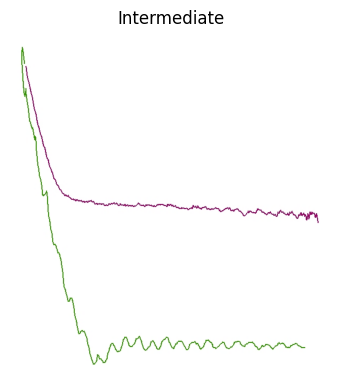

Nanodomain: Nanodomain1.jpg -> original shape (676, 628, 3)


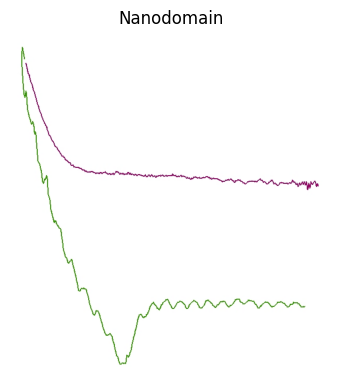

Outside: Outside1.jpg -> original shape (676, 628, 3)


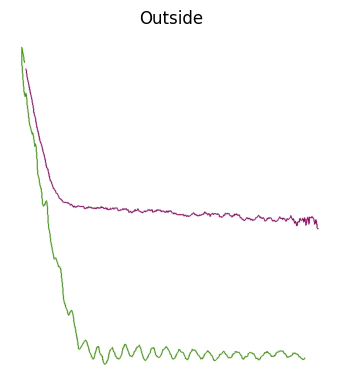

In [4]:
for class_name in CLASS_NAMES:
    class_dir = base_dir / class_name
    image_files = sorted(
        p for p in class_dir.iterdir()
        if p.suffix.lower() in {".jpg", ".jpeg", ".png", ".bmp"}
    )
    if not image_files:
        raise RuntimeError(f"No image files found in {class_dir}")

    sample_path = image_files[0]
    img = tf.keras.utils.load_img(sample_path)
    arr = tf.keras.utils.img_to_array(img)

    print(f"{class_name}: {sample_path.name} -> original shape {arr.shape}")

    plt.figure(figsize=(5, 4))
    plt.imshow(img)
    plt.title(class_name)
    plt.axis("off")
    plt.tight_layout()
    plt.show()

## 2. CNN architecture with L2 kernel regularisation

The CNN architecture is identical to the imbalanced baseline. L2 kernel regularisation
(λ = 0.001) is applied to the five convolutional layers and the two hidden dense layers.
The Softmax output layer is intentionally left unregularised.

No Dropout, data augmentation, class weighting, or resampling is used. Thus, the only
difference from the imbalanced baseline is the L2 penalty.

In [5]:
tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(SEED)

inputs = tf.keras.Input(
    shape=(IMG_SIZE, IMG_SIZE, 3),
    name="fd_curve_image"
)

l2_regularizer = tf.keras.regularizers.l2(L2_FACTOR)

x = layers.Conv2D(
    32, (3, 3),
    activation="relu",
    kernel_regularizer=l2_regularizer,
    name="conv_32"
)(inputs)
x = layers.MaxPooling2D((2, 2), name="pool_1")(x)

x = layers.Conv2D(
    64, (3, 3),
    activation="relu",
    kernel_regularizer=l2_regularizer,
    name="conv_64"
)(x)
x = layers.MaxPooling2D((2, 2), name="pool_2")(x)

x = layers.Conv2D(
    128, (3, 3),
    activation="relu",
    kernel_regularizer=l2_regularizer,
    name="conv_128"
)(x)
x = layers.MaxPooling2D((2, 2), name="pool_3")(x)

x = layers.Conv2D(
    256, (3, 3),
    activation="relu",
    kernel_regularizer=l2_regularizer,
    name="conv_256_1"
)(x)
x = layers.MaxPooling2D((2, 2), name="pool_4")(x)

x = layers.Conv2D(
    256, (3, 3),
    activation="relu",
    kernel_regularizer=l2_regularizer,
    name="conv_256_2"
)(x)

x = layers.Flatten(name="flatten")(x)

x = layers.Dense(
    512,
    activation="relu",
    kernel_regularizer=l2_regularizer,
    name="dense_512"
)(x)

x = layers.Dense(
    128,
    activation="relu",
    kernel_regularizer=l2_regularizer,
    name="dense_128"
)(x)

outputs = layers.Dense(
    3,
    activation="softmax",
    name="class_probabilities"
)(x)

model = Model(
    inputs=inputs,
    outputs=outputs,
    name="CNN_CAlbicans_Imbalanced_L2"
)

model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=LEARNING_RATE
    ),
    loss=tf.keras.losses.CategoricalCrossentropy(),
    metrics=["accuracy"],
)

model.summary()

print("Total parameters:", model.count_params())
assert model.count_params() == 14_152_259

regularised_layers = [
    layer.name
    for layer in model.layers
    if getattr(layer, "kernel_regularizer", None) is not None
]

expected_regularised_layers = [
    "conv_32",
    "conv_64",
    "conv_128",
    "conv_256_1",
    "conv_256_2",
    "dense_512",
    "dense_128",
]

assert regularised_layers == expected_regularised_layers, (
    f"Unexpected regularised layers: {regularised_layers}"
)

assert model.get_layer("class_probabilities").kernel_regularizer is None

print("L2-regularised layers:", regularised_layers)
print("L2 factor:", L2_FACTOR)

2026-08-25 20:41:57.734163: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-08-25 20:41:57.734319: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-08-25 20:41:57.734364: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-08-25 20:41:57.899825: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-08-25 20:41:57.899901: I external/local_xla/xla/stream_executor

Model: "CNN_CAlbicans_Imbalanced_L2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 fd_curve_image (InputLayer  [(None, 224, 224, 3)]     0         
 )                                                               
                                                                 
 conv_32 (Conv2D)            (None, 222, 222, 32)      896       
                                                                 
 pool_1 (MaxPooling2D)       (None, 111, 111, 32)      0         
                                                                 
 conv_64 (Conv2D)            (None, 109, 109, 64)      18496     
                                                                 
 pool_2 (MaxPooling2D)       (None, 54, 54, 64)        0         
                                                                 
 conv_128 (Conv2D)           (None, 52, 52, 128)       73856     
                                       

## 3. Training

The best full model is selected using the **minimum validation loss** and saved as
`CNN_CAlbicans_Imbalanced_L2.h5`.

`steps_per_epoch` and `validation_steps` are intentionally omitted. Keras therefore
processes the complete training and validation iterators, including the final validation
batch of 24 images (`600 = 18×32 + 24`).

In [6]:
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    filepath=str(MODEL_PATH),
    monitor="val_loss",
    mode="min",
    save_best_only=True,
    save_weights_only=False,
    verbose=1,
)

start_time = time.perf_counter()

history = model.fit(
    train_iterator,
    epochs=EPOCHS,
    validation_data=validation_iterator,
    callbacks=[checkpoint],
    verbose=1,
)

training_time_minutes = (time.perf_counter() - start_time) / 60.0
print(f"Total training time: {training_time_minutes:.2f} minutes")

history_df = pd.DataFrame(history.history)
history_df.index = np.arange(1, len(history_df) + 1)
history_df.index.name = "epoch"
history_df.to_csv(RESULTS_DIR / "CNN_CAlbicans_Imbalanced_L2_history.csv")

best_epoch = int(history_df["val_loss"].idxmin())
best_val_loss = float(history_df.loc[best_epoch, "val_loss"])
best_val_accuracy_during_fit = float(history_df.loc[best_epoch, "val_accuracy"])

training_summary = {
    "seed": SEED,
    "image_size": IMG_SIZE,
    "batch_size": BATCH_SIZE,
    "epochs_requested": EPOCHS,
    "learning_rate": LEARNING_RATE,
    "regularisation": "L2",
    "l2_factor": L2_FACTOR,
    "training_samples": int(train_iterator.samples),
    "training_class_counts": training_class_counts,
    "validation_samples": int(validation_iterator.samples),
    "validation_class_counts": validation_class_counts,
    "training_time_minutes": training_time_minutes,
    "best_epoch_by_val_loss": best_epoch,
    "best_val_loss": best_val_loss,
    "val_accuracy_at_best_val_loss_epoch": best_val_accuracy_during_fit,
    "model_path": str(MODEL_PATH),
}

with open(RESULTS_DIR / "CNN_CAlbicans_Imbalanced_L2_training_summary.json", "w") as f:
    json.dump(training_summary, f, indent=2)

print(training_summary)

Epoch 1/50


2026-08-25 20:42:05.061741: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8907
2026-08-25 20:42:05.798550: I external/local_xla/xla/service/service.cc:168] XLA service 0x73d590bdc2b0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-08-25 20:42:05.798647: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA RTX 5000 Ada Generation Laptop GPU, Compute Capability 8.9
2026-08-25 20:42:05.812377: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1787712125.904069  370717 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


58/58 [==============================] - ETA: 0s - loss: 1.7232 - accuracy: 0.8810
Epoch 1: val_loss improved from inf to 1.27602, saving model to Models/CNN_CAlbicans_Imbalanced_L2.h5


/home/adrian/anaconda3/envs/TFQ/lib/python3.11/site-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


58/58 [==============================] - 11s 118ms/step - loss: 1.7232 - accuracy: 0.8810 - val_loss: 1.2760 - val_accuracy: 0.9652
Epoch 2/50
58/58 [==============================] - ETA: 0s - loss: 1.0671 - accuracy: 0.9837
Epoch 2: val_loss improved from 1.27602 to 0.92407, saving model to Models/CNN_CAlbicans_Imbalanced_L2.h5
58/58 [==============================] - 8s 130ms/step - loss: 1.0671 - accuracy: 0.9837 - val_loss: 0.9241 - val_accuracy: 0.9913
Epoch 3/50
58/58 [==============================] - ETA: 0s - loss: 0.8495 - accuracy: 0.9891
Epoch 3: val_loss improved from 0.92407 to 0.76859, saving model to Models/CNN_CAlbicans_Imbalanced_L2.h5
58/58 [==============================] - 8s 132ms/step - loss: 0.8495 - accuracy: 0.9891 - val_loss: 0.7686 - val_accuracy: 0.9913
Epoch 4/50
58/58 [==============================] - ETA: 0s - loss: 0.7342 - accuracy: 0.9886
Epoch 4: val_loss improved from 0.76859 to 0.68652, saving model to Models/CNN_CAlbicans_Imbalanced_L2.h5
58/58 

Epoch 27/50
58/58 [==============================] - ETA: 0s - loss: 0.1631 - accuracy: 0.9935
Epoch 27: val_loss improved from 0.16764 to 0.15856, saving model to Models/CNN_CAlbicans_Imbalanced_L2.h5
58/58 [==============================] - 7s 124ms/step - loss: 0.1631 - accuracy: 0.9935 - val_loss: 0.1586 - val_accuracy: 0.9913
Epoch 28/50
58/58 [==============================] - ETA: 0s - loss: 0.1567 - accuracy: 0.9940
Epoch 28: val_loss improved from 0.15856 to 0.14961, saving model to Models/CNN_CAlbicans_Imbalanced_L2.h5
58/58 [==============================] - 7s 126ms/step - loss: 0.1567 - accuracy: 0.9940 - val_loss: 0.1496 - val_accuracy: 0.9978
Epoch 29/50
58/58 [==============================] - ETA: 0s - loss: 0.1523 - accuracy: 0.9946
Epoch 29: val_loss improved from 0.14961 to 0.14307, saving model to Models/CNN_CAlbicans_Imbalanced_L2.h5
58/58 [==============================] - 7s 119ms/step - loss: 0.1523 - accuracy: 0.9946 - val_loss: 0.1431 - val_accuracy: 0.9957
E

### 3.1. Training and validation loss

Training and validation losses are plotted independently. Because Keras includes the L2
penalty in `loss` and `val_loss`, raw loss magnitudes should not be used as the principal
between-model comparison against the unregularised baseline. Minimum validation loss remains
appropriate for selecting the best checkpoint within this L2 experiment.

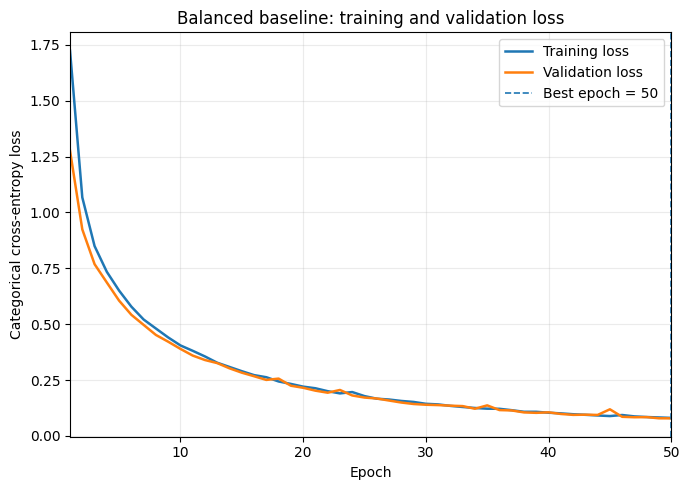

Best epoch by validation loss: 50
Minimum validation loss: 0.078926
Figure saved to: Results/CNN_CAlbicans_Imbalanced_L2_Loss.png


In [7]:
# Independent plot: training and validation loss

history_df_plot = pd.DataFrame(history.history)
epochs_axis = np.arange(1, len(history_df_plot) + 1)

best_epoch_plot = int(np.argmin(history_df_plot["val_loss"].to_numpy()) + 1)
best_val_loss_plot = float(history_df_plot.loc[best_epoch_plot - 1, "val_loss"])

plt.figure(figsize=(7, 5))
plt.plot(
    epochs_axis,
    history_df_plot["loss"],
    linewidth=1.8,
    label="Training loss"
)
plt.plot(
    epochs_axis,
    history_df_plot["val_loss"],
    linewidth=1.8,
    label="Validation loss"
)
plt.axvline(
    best_epoch_plot,
    linestyle="--",
    linewidth=1.2,
    label=f"Best epoch = {best_epoch_plot}"
)

plt.xlabel("Epoch")
plt.ylabel("Categorical cross-entropy loss")
plt.title("Balanced baseline: training and validation loss")
plt.xlim(1, len(epochs_axis))
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()

loss_figure_path = (
    RESULTS_DIR / "CNN_CAlbicans_Imbalanced_L2_Loss.png"
)
plt.savefig(loss_figure_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Best epoch by validation loss: {best_epoch_plot}")
print(f"Minimum validation loss: {best_val_loss_plot:.6f}")
print(f"Figure saved to: {loss_figure_path}")

### 3.2. Training and validation accuracy

Training and validation accuracies are plotted with automatic y-axis scaling. The imbalanced
validation set is also evaluated using balanced accuracy and macro-averaged metrics.

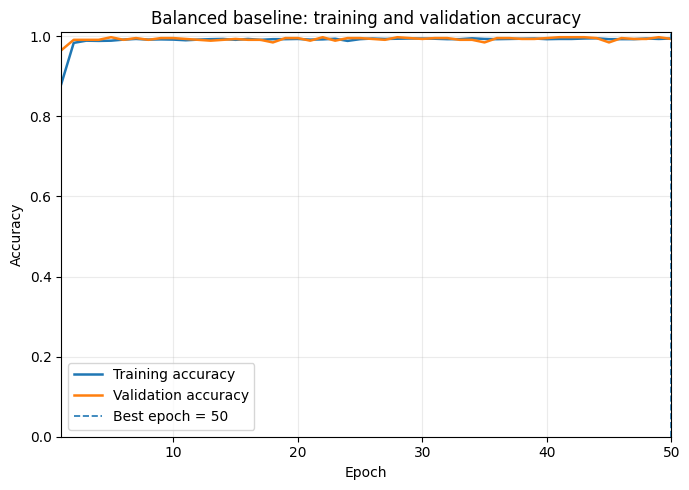

Validation accuracy at the best-loss epoch: 0.993478
Figure saved to: Results/CNN_CAlbicans_Imbalanced_L2_Accuracy.png


In [8]:
# Independent plot: training and validation accuracy

history_df_plot = pd.DataFrame(history.history)
epochs_axis = np.arange(1, len(history_df_plot) + 1)

best_epoch_plot = int(np.argmin(history_df_plot["val_loss"].to_numpy()) + 1)

plt.figure(figsize=(7, 5))
plt.plot(
    epochs_axis,
    history_df_plot["accuracy"],
    linewidth=1.8,
    label="Training accuracy"
)
plt.plot(
    epochs_axis,
    history_df_plot["val_accuracy"],
    linewidth=1.8,
    label="Validation accuracy"
)
plt.axvline(
    best_epoch_plot,
    linestyle="--",
    linewidth=1.2,
    label=f"Best epoch = {best_epoch_plot}"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Balanced baseline: training and validation accuracy")
plt.xlim(1, len(epochs_axis))
plt.ylim(0.0, 1.01)
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()

accuracy_figure_path = (
    RESULTS_DIR / "CNN_CAlbicans_Imbalanced_L2_Accuracy.png"
)
plt.savefig(accuracy_figure_path, dpi=300, bbox_inches="tight")
plt.show()

print(
    "Validation accuracy at the best-loss epoch: "
    f"{history_df_plot.loc[best_epoch_plot - 1, 'val_accuracy']:.6f}"
)
print(f"Figure saved to: {accuracy_figure_path}")

## 4. Validation performance

All 460 validation images are evaluated using the persisted best L2 `.h5` model.

Because the validation set is imbalanced, the principal comparison with the imbalanced
baseline uses overall accuracy, balanced accuracy, macro precision/recall/F1, per-class
metrics, and learning dynamics. Raw `val_loss` values are not compared directly between
the unregularised and L2 objectives.

In [9]:
best_model = load_model(MODEL_PATH)

validation_iterator.reset()
val_probabilities = best_model.predict(validation_iterator, verbose=1)
val_predictions = np.argmax(val_probabilities, axis=1)
val_true = validation_iterator.classes

assert len(val_predictions) == validation_iterator.samples == 460

val_accuracy = accuracy_score(val_true, val_predictions)
val_balanced_accuracy = balanced_accuracy_score(val_true, val_predictions)
val_cm = confusion_matrix(val_true, val_predictions)

report_dict = classification_report(
    val_true,
    val_predictions,
    target_names=CLASS_NAMES,
    output_dict=True,
    zero_division=0,
)

macro_precision = float(report_dict["macro avg"]["precision"])
macro_recall = float(report_dict["macro avg"]["recall"])
macro_f1 = float(report_dict["macro avg"]["f1-score"])
weighted_f1 = float(report_dict["weighted avg"]["f1-score"])

print(f"Validation accuracy:          {val_accuracy:.4f}")
print(f"Validation balanced accuracy: {val_balanced_accuracy:.4f}")
print(f"Macro precision:              {macro_precision:.4f}")
print(f"Macro recall:                 {macro_recall:.4f}")
print(f"Macro F1:                     {macro_f1:.4f}")
print(f"Weighted F1:                  {weighted_f1:.4f}")

print("\nClassification report:")
print(
    classification_report(
        val_true,
        val_predictions,
        target_names=CLASS_NAMES,
        digits=4,
        zero_division=0,
    )
)

pd.DataFrame(report_dict).T.to_csv(
    RESULTS_DIR / "CNN_CAlbicans_Imbalanced_L2_validation_report.csv"
)

validation_summary = {
    "accuracy": float(val_accuracy),
    "balanced_accuracy": float(val_balanced_accuracy),
    "macro_precision": macro_precision,
    "macro_recall": macro_recall,
    "macro_f1": macro_f1,
    "weighted_f1": weighted_f1,
}

with open(
    RESULTS_DIR / "CNN_CAlbicans_Imbalanced_L2_validation_summary.json",
    "w"
) as f:
    json.dump(validation_summary, f, indent=2)

validation_predictions = pd.DataFrame({
    "filename": validation_iterator.filenames,
    "true_label": [CLASS_NAMES[i] for i in val_true],
    "predicted_label": [CLASS_NAMES[i] for i in val_predictions],
})
for idx, class_name in enumerate(CLASS_NAMES):
    validation_predictions[f"prob_{class_name}"] = val_probabilities[:, idx]

validation_predictions.to_csv(
    RESULTS_DIR / "CNN_CAlbicans_Imbalanced_L2_validation_predictions.csv",
    index=False,
)

15/15 [==============================] - 1s 77ms/step
Validation accuracy:          0.9935
Validation balanced accuracy: 0.9929
Macro precision:              0.9925
Macro recall:                 0.9929
Macro F1:                     0.9927
Weighted F1:                  0.9935

Classification report:
              precision    recall  f1-score   support

Intermediate     0.9876    0.9938    0.9907       160
  Nanodomain     1.0000    0.9950    0.9975       200
     Outside     0.9900    0.9900    0.9900       100

    accuracy                         0.9935       460
   macro avg     0.9925    0.9929    0.9927       460
weighted avg     0.9935    0.9935    0.9935       460



### 4.1. Publication-style validation confusion matrix

The confusion matrix is plotted independently using the same visual format intended for
the manuscript. Raw counts are shown in each cell, correctly classified samples on the
main diagonal are labelled **True Positive**, and the overall validation accuracy is
reported below the x-axis. The figure is saved automatically at 300 dpi.

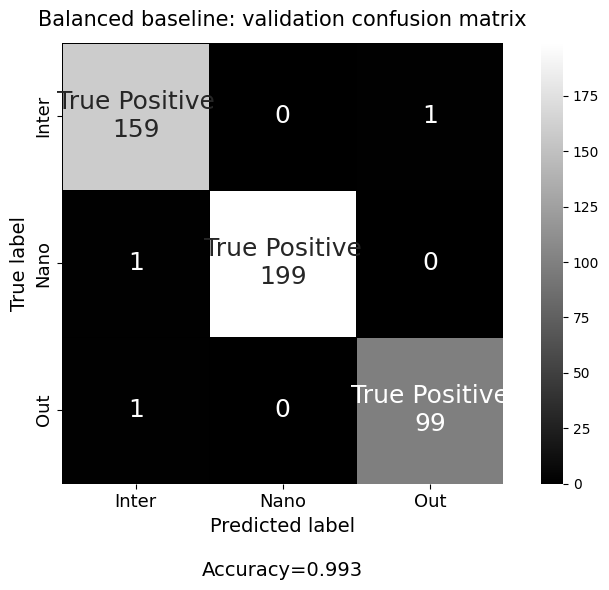

Publication-quality confusion matrix saved to: Results/CNN_CAlbicans_Imbalanced_L2_Validation_ConfusionMatrix.png


In [10]:
# Publication-style confusion matrix
import seaborn as sns

def make_confusion_matrix(
    cf,
    group_names=None,
    categories="auto",
    count=True,
    percent=False,
    cbar=True,
    xyticks=True,
    xyplotlabels=True,
    sum_stats=True,
    figsize=(8, 6),
    cmap="gray",
    title=None,
    save_path=None,
):
    """
    Create a publication-style heatmap from an sklearn confusion matrix.

    Parameters
    ----------
    cf : ndarray
        Confusion matrix.
    group_names : list[str] or None
        Optional text labels for individual matrix cells.
    categories : list[str] or 'auto'
        Class labels shown on the x and y axes.
    count : bool
        Show raw counts in each matrix cell.
    percent : bool
        Show the percentage of the complete matrix in each cell.
    cbar : bool
        Display the colour bar.
    xyticks : bool
        Display class tick labels.
    xyplotlabels : bool
        Display 'True label' and 'Predicted label'.
    sum_stats : bool
        Display overall accuracy below the matrix.
    figsize : tuple
        Matplotlib figure size.
    cmap : str
        Matplotlib/Seaborn colour map.
    title : str or None
        Figure title.
    save_path : str, Path, or None
        Optional output path. When provided, the figure is saved at 300 dpi.
    """

    cf = np.asarray(cf)

    blanks = ["" for _ in range(cf.size)]

    if group_names is not None and len(group_names) == cf.size:
        group_labels = [f"{value}\n" if value else "" for value in group_names]
    else:
        group_labels = blanks

    if count:
        group_counts = [f"{value:0.0f}\n" for value in cf.flatten()]
    else:
        group_counts = blanks

    if percent:
        total = float(np.sum(cf))
        if total > 0:
            group_percentages = [
                f"{value / total:.1%}" for value in cf.flatten()
            ]
        else:
            group_percentages = blanks
    else:
        group_percentages = blanks

    box_labels = [
        f"{label}{n}{pct}".strip()
        for label, n, pct in zip(
            group_labels,
            group_counts,
            group_percentages,
        )
    ]
    box_labels = np.asarray(box_labels).reshape(cf.shape)

    # Overall accuracy
    if sum_stats:
        total = float(np.sum(cf))
        accuracy = np.trace(cf) / total if total > 0 else np.nan
        stats_text = f"\n\nAccuracy={accuracy:0.3f}"
    else:
        stats_text = ""

    if not xyticks:
        categories = False

    fig, ax = plt.subplots(figsize=figsize)

    sns.heatmap(
        cf,
        annot=box_labels,
        fmt="",
        cmap=cmap,
        cbar=cbar,
        xticklabels=categories,
        yticklabels=categories,
        annot_kws={"fontsize": 18},
        linewidths=0.5,
        linecolor="black",
        square=True,
        ax=ax,
    )

    if xyplotlabels:
        ax.set_ylabel("True label", fontsize=14)
        ax.set_xlabel("Predicted label" + stats_text, fontsize=14)
    else:
        ax.set_xlabel(stats_text, fontsize=14)

    ax.tick_params(axis="both", labelsize=13)

    if title:
        ax.set_title(title, fontsize=15, pad=12)

    fig.tight_layout()

    if save_path is not None:
        fig.savefig(
            save_path,
            dpi=300,
            bbox_inches="tight",
        )

    plt.show()
    return ax


# Matrix already calculated from all 600 validation images:
# val_cm = confusion_matrix(val_true, val_predictions)

paper_cell_labels = [
    "True Positive", "", "",
    "", "True Positive", "",
    "", "", "True Positive",
]

paper_categories = ["Inter", "Nano", "Out"]

validation_cm_path = (
    RESULTS_DIR
    / "CNN_CAlbicans_Imbalanced_L2_Validation_ConfusionMatrix.png"
)

make_confusion_matrix(
    val_cm,
    group_names=paper_cell_labels,
    categories=paper_categories,
    count=True,
    percent=False,
    cbar=True,
    xyticks=True,
    xyplotlabels=True,
    sum_stats=True,
    figsize=(8, 6),
    cmap="gray",
    title="Balanced baseline: validation confusion matrix",
    save_path=validation_cm_path,
)

print(f"Publication-quality confusion matrix saved to: {validation_cm_path}")

## 5. Independent imbalanced blind test set from the second *Candida albicans* cell

The original independent imbalanced test contains **855 anonymised curves** with known
aggregate composition:

- 290 Intermediate
- 280 Nanodomain
- 285 Outside

As with the balanced blind test, the CNN performs inference before any optional sample-level
ground-truth CSV is loaded. Without a filename-to-label mapping, the predicted class
distribution can be compared with the known aggregate composition, but it must **not** be
reported as sample-level accuracy.

Independent imbalanced blind-test images found: 855

Loaded model: Models/CNN_CAlbicans_Imbalanced_L2.h5
27/27 [==============================] - 0s 11ms/step

Known aggregate test composition:
Intermediate    290
Nanodomain      280
Outside         285
dtype: int64

Predicted class counts:
predicted_label
Intermediate    288
Nanodomain      280
Outside         287
Name: count, dtype: int64

Aggregate comparison:
              known_aggregate_count  predicted_count  difference
Intermediate                    290              288          -2
Nanodomain                      280              280           0
Outside                         285              287           2

Total blind-test inference time: 0.45 s
Average inference time per FD curve: 0.528 ms
Throughput: 1893.3 FD curves/s
Mean maximum predicted probability: 0.9885
Median maximum predicted probability: 0.9906


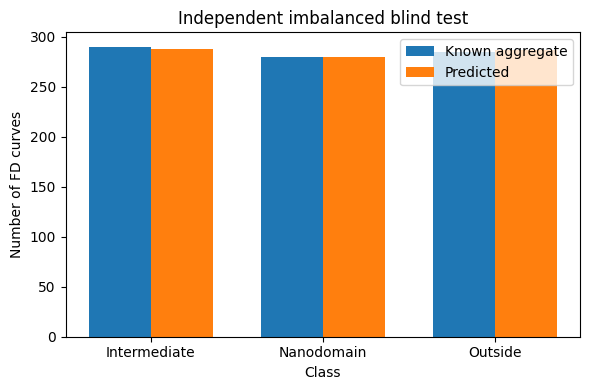


No TestingAdrianImbalance_labels.csv was found. Sample-level independent-test accuracy/F1/confusion matrix will therefore NOT be reported.


In [11]:
# ============================================================
# 5. Independent imbalanced blind test set from a different cell
# ============================================================

import re

# Optional hidden sample-level ground truth.
# Format:
# filename,true_label
GROUND_TRUTH_CSV = (PROJECT_ROOT / "data/labels/cross_cell_imbalanced_label_mapping.csv")

EXPECTED_TEST_COUNTS = {
    "Intermediate": 290,
    "Nanodomain": 280,
    "Outside": 285,
}
EXPECTED_TEST_TOTAL = sum(EXPECTED_TEST_COUNTS.values())  # 855

# ------------------------------------------------------------
# 1. Extract the anonymised test images
# ------------------------------------------------------------
extract_zip_clean(TEST_ZIP, TEST_EXTRACT_DIR)

SUPPORTED_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp"}

def natural_test_key(path):
    match = re.search(r"(\d+)(?=\.[^.]+$)", Path(path).name)
    return int(match.group(1)) if match else Path(path).name

blind_test_files = sorted(
    [
        p for p in TEST_EXTRACT_DIR.rglob("*")
        if p.is_file() and p.suffix.lower() in SUPPORTED_EXTENSIONS
    ],
    key=natural_test_key,
)

print(f"Independent imbalanced blind-test images found: {len(blind_test_files)}")

if len(blind_test_files) != EXPECTED_TEST_TOTAL:
    raise RuntimeError(
        f"Expected {EXPECTED_TEST_TOTAL} independent test images, "
        f"found {len(blind_test_files)}."
    )

# ------------------------------------------------------------
# 2. Preprocess exactly as in training/validation
# ------------------------------------------------------------
def load_blind_test_image(path):
    image_bytes = tf.io.read_file(path)
    image = tf.io.decode_image(
        image_bytes,
        channels=3,
        expand_animations=False,
    )
    image.set_shape([None, None, 3])
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
    image = tf.cast(image, tf.float32) / 255.0
    return image

blind_test_paths = [str(p) for p in blind_test_files]

blind_test_dataset = (
    tf.data.Dataset.from_tensor_slices(blind_test_paths)
    .map(
        load_blind_test_image,
        num_parallel_calls=tf.data.AUTOTUNE,
        deterministic=True,
    )
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

# ------------------------------------------------------------
# 3. Reload the persisted best H5 model
# ------------------------------------------------------------
blind_test_model = load_model(MODEL_PATH)
print("\nLoaded model:", MODEL_PATH)

for warmup_batch in blind_test_dataset.take(1):
    _ = blind_test_model(warmup_batch, training=False)

# ------------------------------------------------------------
# 4. Blind inference
# ------------------------------------------------------------
test_start = time.perf_counter()

blind_test_probabilities = blind_test_model.predict(
    blind_test_dataset,
    verbose=1,
)

test_time_seconds = time.perf_counter() - test_start

blind_test_predictions = np.argmax(blind_test_probabilities, axis=1)
max_predicted_probability = np.max(blind_test_probabilities, axis=1)

# ------------------------------------------------------------
# 5. Save sample-level predictions
# ------------------------------------------------------------
blind_test_df = pd.DataFrame({
    "filename": [p.name for p in blind_test_files],
    "predicted_label": [CLASS_NAMES[i] for i in blind_test_predictions],
    "maximum_predicted_probability": max_predicted_probability,
})

for idx, class_name in enumerate(CLASS_NAMES):
    blind_test_df[f"prob_{class_name}"] = blind_test_probabilities[:, idx]

blind_predictions_path = (
    RESULTS_DIR
    / "CNN_CAlbicans_Imbalanced_L2_blind_test_predictions.csv"
)

blind_test_df.to_csv(blind_predictions_path, index=False)

# ------------------------------------------------------------
# 6. Predicted distribution vs known aggregate composition
# ------------------------------------------------------------
predicted_counts = (
    blind_test_df["predicted_label"]
    .value_counts()
    .reindex(CLASS_NAMES, fill_value=0)
)

expected_counts_series = pd.Series(EXPECTED_TEST_COUNTS).reindex(CLASS_NAMES)

aggregate_comparison = pd.DataFrame({
    "known_aggregate_count": expected_counts_series,
    "predicted_count": predicted_counts,
})
aggregate_comparison["difference"] = (
    aggregate_comparison["predicted_count"]
    - aggregate_comparison["known_aggregate_count"]
)

print("\nKnown aggregate test composition:")
print(expected_counts_series)

print("\nPredicted class counts:")
print(predicted_counts)

print("\nAggregate comparison:")
print(aggregate_comparison)

aggregate_comparison.to_csv(
    RESULTS_DIR
    / "CNN_CAlbicans_Imbalanced_L2_blind_test_aggregate_comparison.csv"
)

n_blind_test = len(blind_test_files)
blind_time_per_curve_ms = (test_time_seconds / n_blind_test) * 1000.0
blind_throughput = n_blind_test / test_time_seconds

print(f"\nTotal blind-test inference time: {test_time_seconds:.2f} s")
print(f"Average inference time per FD curve: {blind_time_per_curve_ms:.3f} ms")
print(f"Throughput: {blind_throughput:.1f} FD curves/s")
print(
    "Mean maximum predicted probability: "
    f"{max_predicted_probability.mean():.4f}"
)
print(
    "Median maximum predicted probability: "
    f"{np.median(max_predicted_probability):.4f}"
)

plt.figure(figsize=(6, 4))
x = np.arange(len(CLASS_NAMES))
width = 0.36
plt.bar(x - width/2, expected_counts_series.values, width, label="Known aggregate")
plt.bar(x + width/2, predicted_counts.values, width, label="Predicted")
plt.xticks(x, CLASS_NAMES)
plt.ylabel("Number of FD curves")
plt.xlabel("Class")
plt.title("Independent imbalanced blind test")
plt.legend()
plt.tight_layout()
plt.show()

# ============================================================
# 7. OPTIONAL sample-level ground-truth evaluation
# ============================================================
if GROUND_TRUTH_CSV.exists():

    labels_df = pd.read_csv(GROUND_TRUTH_CSV)

    required_columns = {"filename", "true_label"}
    if not required_columns.issubset(labels_df.columns):
        raise ValueError(
            "TestingAdrianImbalance_labels.csv must contain: "
            "filename,true_label"
        )

    labels_df = labels_df[["filename", "true_label"]].copy()

    if labels_df["filename"].duplicated().any():
        raise ValueError("Duplicate filenames found in ground-truth CSV.")

    if len(labels_df) != EXPECTED_TEST_TOTAL:
        raise ValueError(
            f"Expected {EXPECTED_TEST_TOTAL} labels, found {len(labels_df)}."
        )

    invalid_labels = sorted(
        set(labels_df["true_label"]) - set(CLASS_NAMES)
    )
    if invalid_labels:
        raise ValueError(
            f"Unknown labels: {invalid_labels}. Expected: {CLASS_NAMES}"
        )

    true_counts = (
        labels_df["true_label"]
        .value_counts()
        .reindex(CLASS_NAMES, fill_value=0)
    )

    if not true_counts.equals(expected_counts_series):
        raise ValueError(
            "Sample-level ground truth does not match the intended "
            f"aggregate composition: {EXPECTED_TEST_COUNTS}"
        )

    evaluated_df = blind_test_df.merge(
        labels_df,
        on="filename",
        how="left",
        validate="one_to_one",
    )

    if evaluated_df["true_label"].isna().any():
        raise ValueError("Ground-truth labels are missing for some files.")

    y_true = evaluated_df["true_label"].to_numpy()
    y_pred = evaluated_df["predicted_label"].to_numpy()

    test_accuracy = accuracy_score(y_true, y_pred)
    test_balanced_accuracy = balanced_accuracy_score(y_true, y_pred)

    test_report = classification_report(
        y_true,
        y_pred,
        labels=CLASS_NAMES,
        target_names=CLASS_NAMES,
        output_dict=True,
        zero_division=0,
    )

    print("\nIndependent imbalanced blind-test performance")
    print(f"Accuracy:          {test_accuracy:.4f}")
    print(f"Balanced accuracy: {test_balanced_accuracy:.4f}")
    print(
        f"Macro F1:          "
        f"{test_report['macro avg']['f1-score']:.4f}"
    )

    print("\nClassification report:")
    print(
        classification_report(
            y_true,
            y_pred,
            labels=CLASS_NAMES,
            target_names=CLASS_NAMES,
            digits=4,
            zero_division=0,
        )
    )

    test_cm = confusion_matrix(
        y_true,
        y_pred,
        labels=CLASS_NAMES,
    )

    independent_cm_path = (
        RESULTS_DIR
        / "CNN_CAlbicans_Imbalanced_L2_IndependentTest_ConfusionMatrix.png"
    )

    make_confusion_matrix(
        test_cm,
        group_names=paper_cell_labels,
        categories=paper_categories,
        count=True,
        percent=False,
        cbar=True,
        xyticks=True,
        xyplotlabels=True,
        sum_stats=True,
        figsize=(8, 6),
        cmap="gray",
        title="Independent imbalanced blind-test confusion matrix",
        save_path=independent_cm_path,
    )

    pd.DataFrame(test_report).T.to_csv(
        RESULTS_DIR
        / "CNN_CAlbicans_Imbalanced_L2_independent_test_report.csv"
    )

else:
    print(
        "\nNo TestingAdrianImbalance_labels.csv was found. "
        "Sample-level independent-test accuracy/F1/confusion matrix "
        "will therefore NOT be reported."
    )

## 6. Classification of the complete 16,384-curve AFM force map

The same complete 128 × 128 map from the independent *Candida albicans* cell is evaluated
to compare operational predictions and inference speed with the balanced-training models.

Full-map images found: 16384
512/512 [==============================] - 6s 12ms/step
Full-map class counts: {'Intermediate': 4614, 'Nanodomain': 7432, 'Outside': 4338}
Total inference time for 16,384 FD curves: 6.70 s
Average inference time per FD curve: 0.409 ms
Throughput: 2445.7 FD curves/s


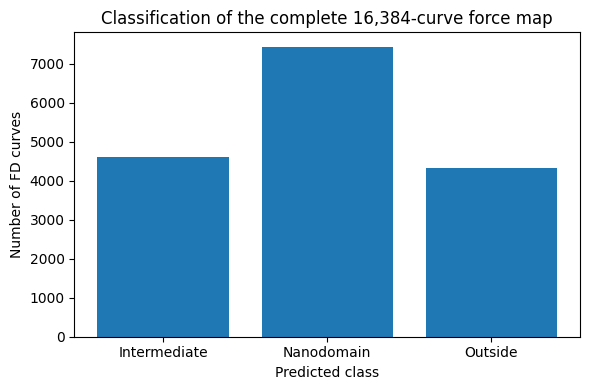

In [12]:
extract_zip_clean(FULL_MAP_ZIP, FULL_MAP_EXTRACT_DIR)

SUPPORTED_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp"}
full_map_files = sorted(
    p
    for p in FULL_MAP_EXTRACT_DIR.rglob("*")
    if p.is_file() and p.suffix.lower() in SUPPORTED_EXTENSIONS
)

print("Full-map images found:", len(full_map_files))
if len(full_map_files) != 16_384:
    raise RuntimeError(
        f"Expected 16,384 force-distance curve images, found {len(full_map_files)}."
    )

full_map_paths = [str(p) for p in full_map_files]

def load_and_preprocess_unlabelled_image(path):
    image_bytes = tf.io.read_file(path)
    image = tf.io.decode_image(
        image_bytes,
        channels=3,
        expand_animations=False,
    )
    image.set_shape([None, None, 3])
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
    image = tf.cast(image, tf.float32) / 255.0
    return image

full_map_dataset = (
    tf.data.Dataset.from_tensor_slices(full_map_paths)
    .map(
        load_and_preprocess_unlabelled_image,
        num_parallel_calls=tf.data.AUTOTUNE,
        deterministic=True,
    )
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

# Warm-up to reduce one-time tracing/initialisation overhead in the timed measurement.
for warmup_batch in full_map_dataset.take(1):
    _ = best_model(warmup_batch, training=False)

full_map_start = time.perf_counter()
full_map_probabilities = best_model.predict(full_map_dataset, verbose=1)
full_map_time_seconds = time.perf_counter() - full_map_start

full_map_predictions = np.argmax(full_map_probabilities, axis=1)

unique, counts = np.unique(full_map_predictions, return_counts=True)
class_counts = {
    CLASS_NAMES[int(class_idx)]: int(count)
    for class_idx, count in zip(unique, counts)
}

n_full_map = len(full_map_files)
full_map_time_per_curve_ms = (full_map_time_seconds / n_full_map) * 1000.0
full_map_throughput = n_full_map / full_map_time_seconds

print("Full-map class counts:", class_counts)
print(
    f"Total inference time for {n_full_map:,} FD curves: "
    f"{full_map_time_seconds:.2f} s"
)
print(f"Average inference time per FD curve: {full_map_time_per_curve_ms:.3f} ms")
print(f"Throughput: {full_map_throughput:.1f} FD curves/s")

full_map_df = pd.DataFrame({
    "filename": [p.name for p in full_map_files],
    "predicted_label": [CLASS_NAMES[i] for i in full_map_predictions],
})
for idx, class_name in enumerate(CLASS_NAMES):
    full_map_df[f"prob_{class_name}"] = full_map_probabilities[:, idx]

full_map_df.to_csv(
    RESULTS_DIR / "CNN_CAlbicans_Imbalanced_L2_full_map_predictions.csv",
    index=False,
)

plt.figure(figsize=(6, 4))
plt.bar(list(class_counts.keys()), list(class_counts.values()))
plt.ylabel("Number of FD curves")
plt.xlabel("Predicted class")
plt.title("Classification of the complete 16,384-curve force map")
plt.tight_layout()
plt.show()

### 6.1. Computational performance summary

This cell consolidates the training time and the two inference experiments performed with
the persisted baseline model: the 900-curve blind independent test and the complete
16,384-curve force map from the same second *Candida albicans* cell.

In [13]:
# Consolidated computational-performance summary

performance_summary = {
    "model": "CNN_CAlbicans_Imbalanced_L2",
    "training_time_minutes": float(training_time_minutes),
    "blind_test_curves": int(len(blind_test_files)),
    "blind_test_inference_time_seconds": float(test_time_seconds),
    "blind_test_time_per_curve_ms": float(blind_time_per_curve_ms),
    "blind_test_throughput_curves_per_second": float(blind_throughput),
    "full_map_curves": int(len(full_map_files)),
    "full_map_inference_time_seconds": float(full_map_time_seconds),
    "full_map_time_per_curve_ms": float(full_map_time_per_curve_ms),
    "full_map_throughput_curves_per_second": float(full_map_throughput),
}

performance_df = pd.DataFrame([performance_summary])
display(performance_df)

performance_path = (
    RESULTS_DIR
    / "CNN_CAlbicans_Imbalanced_L2_ComputationalPerformance.csv"
)

performance_df.to_csv(performance_path, index=False)

print(f"Computational-performance summary saved to: {performance_path}")

,model,training_time_minutes,blind_test_curves,blind_test_inference_time_seconds,blind_test_time_per_curve_ms,blind_test_throughput_curves_per_second,full_map_curves,full_map_inference_time_seconds,full_map_time_per_curve_ms,full_map_throughput_curves_per_second
0,CNN_CAlbicans_Imbalanced_L2,6.154791,855,0.451589,0.528175,1893.31271,16384,6.699172,0.408885,2445.675466


Computational-performance summary saved to: Results/CNN_CAlbicans_Imbalanced_L2_ComputationalPerformance.csv


## 7. Output files

After a complete run, the notebook produces:

- `Models/CNN_CAlbicans_Imbalanced_L2.h5`
- training history and training summary
- loss and accuracy figures
- validation accuracy, balanced accuracy, macro metrics, per-class metrics and confusion matrix
- 855-curve independent imbalanced blind-test predictions
- aggregate known-vs-predicted class-count comparison
- optional supervised independent-test metrics if `TestingAdrianImbalance_labels.csv` is available
- complete 16,384-curve force-map predictions
- computational-performance summary

This notebook is intended for direct comparison with
`CNN_CAlbicans_Imbalanced_Baseline`. The only modelling difference is L2 = 0.001.